# Uncertainty Calibration via Gaussian Consistency Test
Test: $X_{obs} \sim \mathcal{N}(\mu_{pred}, \sigma_{obs}^2 + \sigma_{pred}^2)$ for spectra and images, using the checkpointed model.

In [10]:
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt

repo_root = "/pscratch/sd/p/pzehao/MultiModal"
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from models.MAESimple import MaskedAutoencoderViT
from utils.DataProcessing import CreateMultimodalDataLoadersIter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt_path = "/pscratch/sd/p/pzehao/DESIMAE/ProductionCheckpointsSimple/epoch=096-val_loss=-1.5013.ckpt"
ckpt = torch.load(ckpt_path, map_location="cpu")
model = MaskedAutoencoderViT(**ckpt["hyper_parameters"]).to(device)
model.load_state_dict(ckpt["state_dict"], strict=True)
model.eval()

print({"checkpoint": ckpt_path, "device": str(device)})

/tmp/ipykernel_2230606/4061180163.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location="cpu")


{'checkpoint': '/pscratch/sd/p/pzehao/DESIMAE/ProductionCheckpointsSimple/epoch=096-val_loss=-1.5013.ckpt', 'device': 'cuda'}


In [11]:
# Small eval subset for a quick diagnostic (masked regions only)
loader_cfg = {
    "end": 4737442,
    "train_size": 4642694,
    "batch_size": 32,
    "train_index_mode": "interleave",
    "train_block_size": 100,
    "train_interleave_groups": 4,
    "train_interleave_span": 1,
    "train_subset_size": 25000,
    "train_cycle_epoch": 1,
    "train_cycle_drop_last": False,
    "num_workers": 7,
    "prefetch_factor": 4,
    "distributed_shard_mode": "contiguous",
}
train_loader, val_loader, test_loader = CreateMultimodalDataLoadersIter(**loader_cfg)
n_batches = 20
eps = 1e-8
model.mask_ratio = 0.75
model.mask_ratio_img = 0.75
z_spec_all = []
z_img_all = []

with torch.no_grad():
    for i, batch in enumerate(test_loader):
        if batch is None:
            continue
        if i >= n_batches:
            break

        _, spec, weig, err_obs, img, img_w, img_err_obs, z, xy_pix = batch
        spec = spec.to(device)
        weig = weig.to(device)
        err_obs = err_obs.to(device)
        img = img.to(device)
        img_w = img_w.to(device)
        img_err_obs = img_err_obs.to(device)
        z = z.to(device)
        xy_pix = xy_pix.to(device)

        _, _, _, pred_spec_full, pred_logsig_full, pred_img_flat, pred_img_logsig_flat, token_mask = model.forward(
            spec, weig, err_obs, img, img_w, img_err_obs, z, xy_pix
        )

        B = spec.shape[0]
        offset = model.left_patches * model.patch_size
        pred_spec = pred_spec_full[:, offset:offset + model.spec_dim]
        pred_sigma_spec = torch.exp(pred_logsig_full[:, offset:offset + model.spec_dim]).clamp_min(eps)

        sigma_tot_spec = torch.sqrt(err_obs.pow(2) + pred_sigma_spec.pow(2) + eps)
        z_spec = (spec - pred_spec) / sigma_tot_spec

        spec_mask_tokens = token_mask[:-model.num_patchesimg].bool()
        if spec_mask_tokens.dim() == 1:
            spec_mask_tokens = spec_mask_tokens.unsqueeze(0).expand(B, -1)
        if spec_mask_tokens.shape[-1] > model.num_patches1d:
            spec_mask_tokens = spec_mask_tokens[:, -model.num_patches1d:]
        spec_mask_pix = spec_mask_tokens.repeat_interleave(model.patch_size, dim=1)[:, :model.spec_dim]

        P = model.img_patch
        C = model.num_img_channels
        N = model.patch_embedimg.num_patches
        gh = gw = int(np.sqrt(N))
        img_tokens = pred_img_flat.view(B, model.num_patchesimg, P * P)
        img_logsig_tokens = pred_img_logsig_flat.view(B, model.num_patchesimg, P * P)
        pred_img_map = model._img_tokens_to_image(img_tokens)
        pred_sigma_img = torch.exp(model._img_tokens_to_image(img_logsig_tokens)).clamp_min(eps)

        sigma_tot_img = torch.sqrt(img_err_obs.pow(2) + pred_sigma_img.pow(2) + eps)
        z_img = (img - pred_img_map) / sigma_tot_img

        img_mask_tokens = token_mask[-model.num_patchesimg:].bool()
        if img_mask_tokens.dim() == 1:
            img_mask_tokens = img_mask_tokens.unsqueeze(0).expand(B, -1)
        img_mask_map = img_mask_tokens.view(B, C, N).view(B, C, gh, gw)
        img_mask_map = img_mask_map.repeat_interleave(P, dim=2).repeat_interleave(P, dim=3)

        z_spec_all.append(z_spec[spec_mask_pix].detach().cpu())
        z_img_all.append(z_img[img_mask_map].detach().cpu())

z_spec_all = torch.cat(z_spec_all).numpy() if z_spec_all else np.array([])
z_img_all = torch.cat(z_img_all).numpy() if z_img_all else np.array([])

# Keep finite values only
z_spec_all = z_spec_all[np.isfinite(z_spec_all)]
z_img_all = z_img_all[np.isfinite(z_img_all)]

stats = {
    "spec_median": float(np.median(z_spec_all)) if z_spec_all.size else np.nan,
    "spec_scatter_std": float(np.std(z_spec_all)) if z_spec_all.size else np.nan,
    "spec_scatter_mad": float(1.4826 * np.median(np.abs(z_spec_all - np.median(z_spec_all)))) if z_spec_all.size else np.nan,
    "img_median": float(np.median(z_img_all)) if z_img_all.size else np.nan,
    "img_scatter_std": float(np.std(z_img_all)) if z_img_all.size else np.nan,
    "img_scatter_mad": float(1.4826 * np.median(np.abs(z_img_all - np.median(z_img_all)))) if z_img_all.size else np.nan,
    "n_spec": int(z_spec_all.size),
    "n_img": int(z_img_all.size),
}
stats

{'spec_median': 0.008421486243605614,
 'spec_scatter_std': 1.0120890140533447,
 'spec_scatter_mad': 0.9970939433097838,
 'img_median': -0.014901707880198956,
 'img_scatter_std': 0.8705677390098572,
 'img_scatter_mad': 0.45128823593258854,
 'n_spec': 3736864,
 'n_img': 47185920}

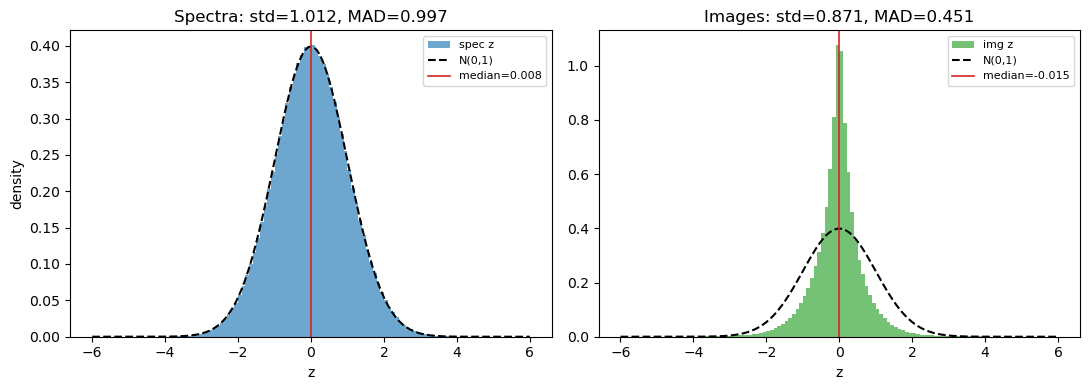

In [12]:
# Quick calibration plots
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
bins = 120
x = np.linspace(-6, 6, 1000)
gauss = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x**2)

axes[0].hist(z_spec_all, bins=bins, range=(-6, 6), density=True, alpha=0.65, color="tab:blue", label="spec z")
axes[0].plot(x, gauss, "k--", lw=1.5, label="N(0,1)")
axes[0].axvline(stats["spec_median"], color="tab:red", lw=1.2, label=f"median={stats['spec_median']:.3f}")
axes[0].set_title(f"Spectra: std={stats['spec_scatter_std']:.3f}, MAD={stats['spec_scatter_mad']:.3f}")
axes[0].set_xlabel("z")
axes[0].set_ylabel("density")
axes[0].legend(fontsize=8)

axes[1].hist(z_img_all, bins=bins, range=(-6, 6), density=True, alpha=0.65, color="tab:green", label="img z")
axes[1].plot(x, gauss, "k--", lw=1.5, label="N(0,1)")
axes[1].axvline(stats["img_median"], color="tab:red", lw=1.2, label=f"median={stats['img_median']:.3f}")
axes[1].set_title(f"Images: std={stats['img_scatter_std']:.3f}, MAD={stats['img_scatter_mad']:.3f}")
axes[1].set_xlabel("z")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [13]:
# Optional compact QQ-style summary using quantiles
q = np.array([0.16, 0.5, 0.84])
print("Spec quantiles (16/50/84):", np.quantile(z_spec_all, q))
print("Img  quantiles (16/50/84):", np.quantile(z_img_all, q))

Spec quantiles (16/50/84): [-0.9810072   0.00842149  1.00507113]
Img  quantiles (16/50/84): [-0.56821113 -0.01490171  0.48433396]


In [14]:
summary = {
    "spec_median": float(stats["spec_median"]),
    "spec_std": float(stats["spec_scatter_std"]),
    "spec_mad_sigma": float(stats["spec_scatter_mad"]),
    "img_median": float(stats["img_median"]),
    "img_std": float(stats["img_scatter_std"]),
    "img_mad_sigma": float(stats["img_scatter_mad"]),
    "n_spec": int(stats["n_spec"]),
    "n_img": int(stats["n_img"]),
}
summary

{'spec_median': 0.008421486243605614,
 'spec_std': 1.0120890140533447,
 'spec_mad_sigma': 0.9970939433097838,
 'img_median': -0.014901707880198956,
 'img_std': 0.8705677390098572,
 'img_mad_sigma': 0.45128823593258854,
 'n_spec': 3736864,
 'n_img': 47185920}

In [ ]:
# 2D mask-ratio sweep (masked regions only)
import pandas as pd

spec_mask_ratios = [1.0, 13/14, 12/14, 11/14, 10/14, 9/14, 8/14, 7/14, 6/14, 5/14, 4/14, 3/14, 2/14, 1/14, 0.0]
img_mask_ratios = [1.0, 13/14, 12/14, 11/14, 10/14, 9/14, 8/14, 7/14, 6/14, 5/14, 4/14, 3/14, 2/14, 1/14, 0.0]
n_batches_sweep = 32

rows = []

def collect_masked_z(spec, err_obs, img, img_err_obs, token_mask, pred_spec_full, pred_logsig_full, pred_img_flat, pred_img_logsig_flat):
    B = spec.shape[0]

    offset = model.left_patches * model.patch_size
    pred_spec = pred_spec_full[:, offset:offset + model.spec_dim]
    pred_sigma_spec = torch.exp(pred_logsig_full[:, offset:offset + model.spec_dim]).clamp_min(eps)
    sigma_tot_spec = torch.sqrt(err_obs.pow(2) + pred_sigma_spec.pow(2) + eps)
    z_spec = (spec - pred_spec) / sigma_tot_spec

    spec_mask_tokens = token_mask[:-model.num_patchesimg].bool()
    if spec_mask_tokens.dim() == 1:
        spec_mask_tokens = spec_mask_tokens.unsqueeze(0).expand(B, -1)
    if spec_mask_tokens.shape[-1] > model.num_patches1d:
        spec_mask_tokens = spec_mask_tokens[:, -model.num_patches1d:]
    spec_mask_pix = spec_mask_tokens.repeat_interleave(model.patch_size, dim=1)[:, :model.spec_dim]

    P = model.img_patch
    C = model.num_img_channels
    N = model.patch_embedimg.num_patches
    gh = gw = int(np.sqrt(N))

    img_tokens = pred_img_flat.view(B, model.num_patchesimg, P * P)
    img_logsig_tokens = pred_img_logsig_flat.view(B, model.num_patchesimg, P * P)
    pred_img_map = model._img_tokens_to_image(img_tokens)
    pred_sigma_img = torch.exp(model._img_tokens_to_image(img_logsig_tokens)).clamp_min(eps)
    sigma_tot_img = torch.sqrt(img_err_obs.pow(2) + pred_sigma_img.pow(2) + eps)
    z_img = (img - pred_img_map) / sigma_tot_img

    img_mask_tokens = token_mask[-model.num_patchesimg:].bool()
    if img_mask_tokens.dim() == 1:
        img_mask_tokens = img_mask_tokens.unsqueeze(0).expand(B, -1)
    img_mask_map = img_mask_tokens.view(B, C, N).view(B, C, gh, gw)
    img_mask_map = img_mask_map.repeat_interleave(P, dim=2).repeat_interleave(P, dim=3)

    out = {}
    out["z_spec"] = z_spec[spec_mask_pix].detach().cpu() if spec_mask_pix.any() else torch.empty(0)
    out["z_img"] = z_img[img_mask_map].detach().cpu() if img_mask_map.any() else torch.empty(0)
    return out

with torch.no_grad():
    for spec_mr in spec_mask_ratios:
        for img_mr in img_mask_ratios:
            model.mask_ratio = spec_mr
            model.mask_ratio_img = img_mr

            z_spec_list = []
            z_img_list = []

            for i, batch in enumerate(test_loader):
                if batch is None:
                    continue
                if i >= n_batches_sweep:
                    break

                _, spec, weig, err_obs, img, img_w, img_err_obs, z, xy_pix = batch
                spec = spec.to(device)
                weig = weig.to(device)
                err_obs = err_obs.to(device)
                img = img.to(device)
                img_w = img_w.to(device)
                img_err_obs = img_err_obs.to(device)
                z = z.to(device)
                xy_pix = xy_pix.to(device)

                _, _, _, pred_spec_full, pred_logsig_full, pred_img_flat, pred_img_logsig_flat, token_mask = model.forward(
                    spec, weig, err_obs, img, img_w, img_err_obs, z, xy_pix
                )

                vals = collect_masked_z(
                    spec=spec,
                    err_obs=err_obs,
                    img=img,
                    img_err_obs=img_err_obs,
                    token_mask=token_mask,
                    pred_spec_full=pred_spec_full,
                    pred_logsig_full=pred_logsig_full,
                    pred_img_flat=pred_img_flat,
                    pred_img_logsig_flat=pred_img_logsig_flat,
                )

                if vals["z_spec"].numel() > 0:
                    z_spec_list.append(vals["z_spec"])
                if vals["z_img"].numel() > 0:
                    z_img_list.append(vals["z_img"])

            z_spec_all = torch.cat(z_spec_list).numpy() if z_spec_list else np.array([])
            z_img_all = torch.cat(z_img_list).numpy() if z_img_list else np.array([])
            z_spec_all = z_spec_all[np.isfinite(z_spec_all)]
            z_img_all = z_img_all[np.isfinite(z_img_all)]

            rows.append({
                "spec_mask_ratio": spec_mr,
                "img_mask_ratio": img_mr,
                "spec_bias": float(np.median(z_spec_all)) if z_spec_all.size else np.nan,
                "spec_std": float(np.std(z_spec_all)) if z_spec_all.size else np.nan,
                "img_bias": float(np.median(z_img_all)) if z_img_all.size else np.nan,
                "img_std": float(np.std(z_img_all)) if z_img_all.size else np.nan,
                "n_spec": int(z_spec_all.size),
                "n_img": int(z_img_all.size),
            })

sweep_df = pd.DataFrame(rows)
sweep_df

,spec_mask_ratio,img_mask_ratio,spec_bias,spec_std,img_bias,img_std,n_spec,n_img
0,1.0,1.000000,-0.435689,1.642054,-0.041923,1.727809,7967744,100663296
1,1.0,0.928571,-0.059697,1.099928,-0.013704,1.062169,7967744,93585408
2,1.0,0.857143,-0.013336,1.095396,-0.013570,0.847213,7967744,86245376
3,1.0,0.785714,-0.034922,1.091338,-0.014186,0.813183,7967744,79167488
4,1.0,0.714286,-0.010592,1.069551,-0.013925,0.763078,7967744,71827456
...,...,...,...,...,...,...,...,...
220,0.0,0.285714,NaN,NaN,-0.002308,0.715219,0,28835840
221,0.0,0.214286,NaN,NaN,0.000033,0.790468,0,21495808
222,0.0,0.142857,NaN,NaN,0.000274,0.703740,0,14417920
223,0.0,0.071429,NaN,NaN,0.000660,0.709404,0,7077888


In [26]:
# save sweep results for later plotting
sweep_df.to_csv("mask_ratio_sweep_results.csv", index=False)

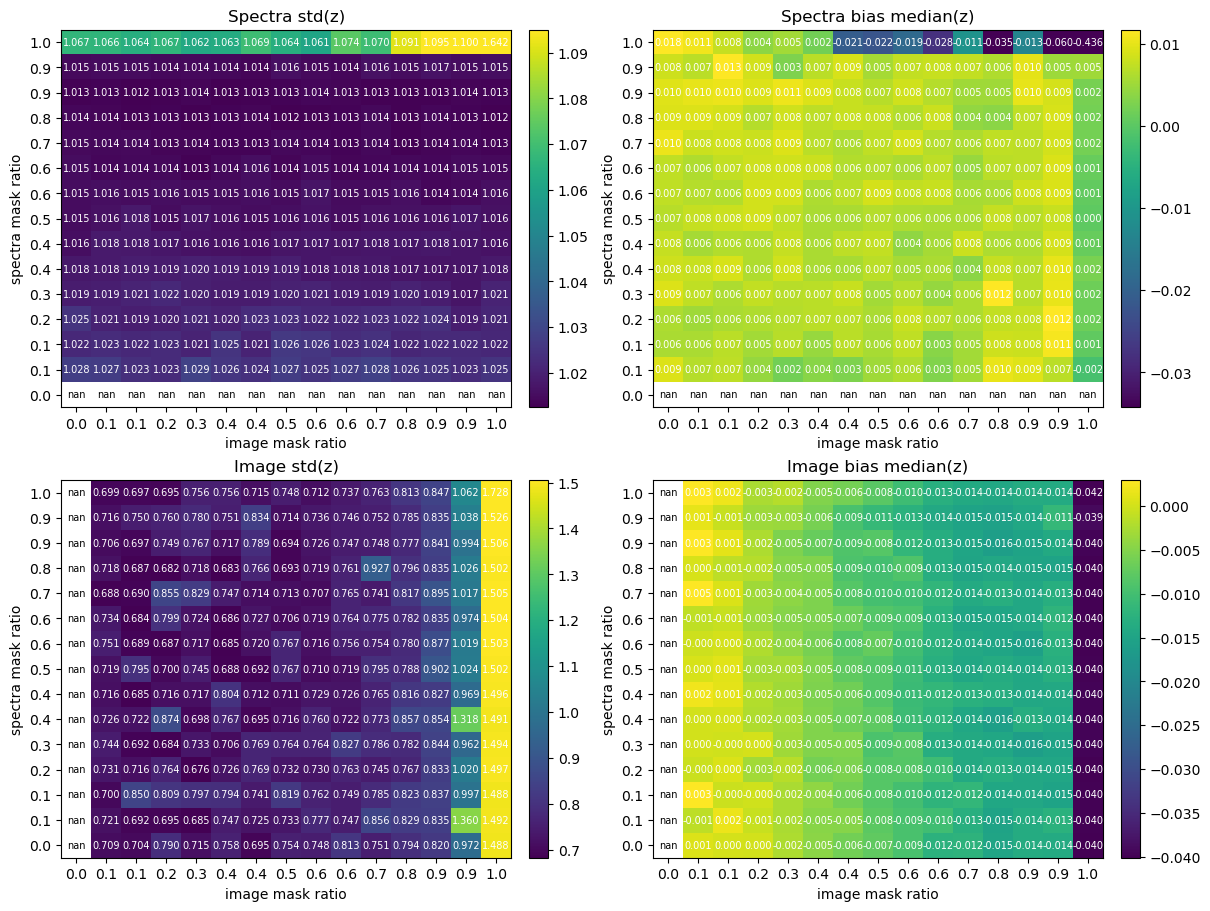

In [25]:
# 4 heatmaps: std and bias for spectra/images over (spec mask ratio, img mask ratio)
metrics = [
    ("spec_std", "Spectra std(z)"),
    ("spec_bias", "Spectra bias median(z)"),
    ("img_std", "Image std(z)"),
    ("img_bias", "Image bias median(z)"),
]

spec_mask_ratios = [1.0, 13/14, 12/14, 11/14, 10/14, 9/14, 8/14, 7/14, 6/14, 5/14, 4/14, 3/14, 2/14, 1/14, 0.0]
img_mask_ratios = [1.0, 13/14, 12/14, 11/14, 10/14, 9/14, 8/14, 7/14, 6/14, 5/14, 4/14, 3/14, 2/14, 1/14, 0.0]

fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)

for ax, (metric, title) in zip(axes.ravel(), metrics):
    # round to 2 decimals for cleaner display
    grid = sweep_df.pivot(index="spec_mask_ratio", columns="img_mask_ratio", values=metric)
    # grid = grid.round(2)
    grid = grid.sort_index().sort_index(axis=1)
    
    # percentiles for vmin and vmax
    im = ax.imshow(grid.to_numpy(), origin="lower", aspect="auto", cmap='viridis', vmin=np.nanpercentile(grid.to_numpy(), 1), vmax=np.nanpercentile(grid.to_numpy(), 99))
    ax.set_title(title)
    ax.set_xlabel("image mask ratio")
    ax.set_ylabel("spectra mask ratio")
    ax.set_xticks(np.arange(len(grid.columns)))
    ax.set_xticklabels([f"{v:.1f}" for v in grid.columns])
    ax.set_yticks(np.arange(len(grid.index)))
    ax.set_yticklabels([f"{v:.1f}" for v in grid.index])

    # Annotate cells for easier reading of exact values.
    vals = grid.to_numpy()
    for r in range(vals.shape[0]):
        for c in range(vals.shape[1]):
            v = vals[r, c]
            txt = "nan" if not np.isfinite(v) else f"{v:.3f}"
            ax.text(c, r, txt, ha="center", va="center", fontsize=7, color="white" if np.isfinite(v) else "black")

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.show()